In [39]:
import pysindy as ps
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

differentiation_method = ps.FiniteDifference(order=2)
feature_library = ps.PolynomialLibrary(degree=2)
optimizer = ps.STLSQ(threshold=0.01)
def lotka_volterra(t, state, a, b, c, d):
    x, y = state
    dxdt = a*x - b*x*y
    dydt = d*x*y - c*y
    return [dxdt, dydt]

amountOfData = np.arange(6,1000,step=1)
results = np.zeros(len(amountOfData))
for index,count in enumerate(amountOfData):
    params = (1.1, 0.4, 0.4, 0.1)
    initial_pop = [10, 5]
    t_span = (0, 100)
    t_eval = np.linspace(0, 100, int(count))

    sol = solve_ivp(
        lotka_volterra,
        t_span,
        initial_pop,
        args=params,
        t_eval=t_eval
    )

    x = sol.y[0]
    y = sol.y[1]
    t = sol.t

    model = ps.SINDy(
        differentiation_method=differentiation_method,
        feature_library=feature_library,
        optimizer=optimizer,
    )
    X = np.stack((x, y), axis=-1)
    model.fit(X, t=t, feature_names=["x", "y"])

    # print("Discovered Equations:")
    # model.print()

    x_sim = model.simulate(initial_pop, t_eval)

    # Extract the 1D arrays for original and simulated data
    x_orig = sol.y[0]
    y_orig = sol.y[1]
    x_simulated = x_sim[:, 0]
    y_simulated = x_sim[:, 1]

    # 1. Mean Squared Error (MSE)
    mse_x = np.mean((x_orig - x_simulated)**2)
    mse_y = np.mean((y_orig - y_simulated)**2)

    # 2. Root Mean Squared Error (RMSE)
    rmse_x = np.sqrt(mse_x)
    rmse_y = np.sqrt(mse_y)

    # print("--- Error Metrics ---")
    # print(f"Prey (x) RMSE: {rmse_x:.4f}")
    # print(f"Predator (y) RMSE: {rmse_y:.4f}")
    results[index] = rmse_x

/Users/jordan/PycharmProjects/AMP3/.venv/lib/python3.13/site-packages/pysindy/optimizers/stlsq.py:234: UserWarning: Sparsity parameter is too big (0.01) and eliminated all coefficients
  warnings.warn(
/Users/jordan/PycharmProjects/AMP3/.venv/lib/python3.13/site-packages/pysindy/utils/_axes.py:389: RuntimeWarning: overflow encountered in reduce
  results = super().__array_ufunc__(ufunc, method, *args, **kwargs)


ValueError: Input X contains infinity or a value too large for dtype('float64').

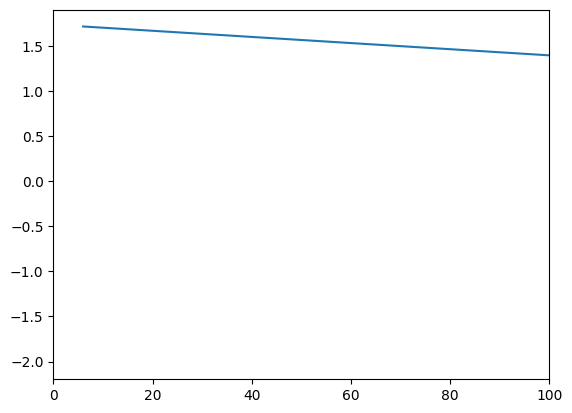

In [33]:
plt.plot(amountOfData,np.log(results))
plt.xlim(0,100)
print()

In [ ]:
import pysindy as ps
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

differentiation_method = ps.FiniteDifference(order=2)
feature_library = ps.PolynomialLibrary(degree=2)
optimizer = ps.STLSQ(threshold=0.01)
def lotka_volterra(t, state, a, b, c, d):
    x, y = state
    dxdt = a*x - b*x*y
    dydt = d*x*y - c*y
    return [dxdt, dydt]

amountOfData = np.arange(6,1000000.1,step=1000)
results2 = np.zeros(len(amountOfData))
params = (1.1, 0.4, 0.4, 0.1)
initial_pop = [10, 5]
t_span = (0, 100)
t_eval = np.linspace(0, 100, int(count))

sol = solve_ivp(
    lotka_volterra,
    t_span,
    initial_pop,
    args=params,
    t_eval=t_eval
)

x = sol.y[0]
y = sol.y[1]
t = sol.t

model = ps.SINDy(
    differentiation_method=differentiation_method,
    feature_library=feature_library,
    optimizer=optimizer,
)
X = np.stack((x, y), axis=-1)
model.fit(X, t=t, feature_names=["x", "y"])
print("Discovered Equations:")
model.print()
for index,count in enumerate(amountOfData):




    x_sim = model.simulate(initial_pop, t_eval)

    # Extract the 1D arrays for original and simulated data
    x_orig = sol.y[0]
    y_orig = sol.y[1]
    x_simulated = x_sim[:, 0]
    y_simulated = x_sim[:, 1]

    # 1. Mean Squared Error (MSE)
    mse_x = np.mean((x_orig - x_simulated)**2)
    mse_y = np.mean((y_orig - y_simulated)**2)

    # 2. Root Mean Squared Error (RMSE)
    rmse_x = np.sqrt(mse_x)
    rmse_y = np.sqrt(mse_y)

    # print("--- Error Metrics ---")
    # print(f"Prey (x) RMSE: {rmse_x:.4f}")
    # print(f"Predator (y) RMSE: {rmse_y:.4f}")
    results[index] = rmse_x